# Aim 1.1: Characterize Real ICH

The goal of this work is to complete Aim 1.1 of the PedSilico ICH Critical Path award.

As outlined in a [GitHub Issue](https://github.com/DIDSR/PedSilicoICH/issues/69), this notebook will summarize the data analysis performed on three external datasets:
* The Hssayeni dataset [EDA Notebook](https://github.com/DIDSR/PedSilicoICH/blob/b2cf0b6c114d624095480e8dfa25dc2f5e78883f/notebooks/00_basic_eda.ipynb), [Dataset Info](https://physionet.org/content/ct-ich/1.3.1/)
* The INSTANCE dataset [EDA Notebook](https://github.com/DIDSR/PedSilicoICH/blob/b2cf0b6c114d624095480e8dfa25dc2f5e78883f/notebooks/instance2022_explore.ipynb)
* The BHSD/RSNA dataset [EDA Notebook](https://github.com/DIDSR/PedSilicoICH/blob/b2cf0b6c114d624095480e8dfa25dc2f5e78883f/notebooks/RSNA_BHSD_explore.ipynb), [Further Analysis Notebook](https://github.com/DIDSR/PedSilicoICH/blob/b2cf0b6c114d624095480e8dfa25dc2f5e78883f/notebooks/RSNA_BHSD_fitting.ipynb)

However, each dataset is organized differently:
* Hssayeni dataset: Presence of hemorrhage type is known, but segmentation mask is type-agnostic (mask = 1 for all hemorrhages)
* INSTANCE dataset: Hemorrhage type is NOT identified, segmentation mask is type-agnostic (mask = 1 for all hemorrhages)
* BHSD: Hemorrhage type is known AND segmentation mask is type-specific (mask = 1 for epidural, = 2 for intraparenchymal, and so on)

As such, this notebook will initially be *type-agnostic*. Unique hemorrhages will be clustered to create distributions of hemorrhage volume and contrast within each dataset.

Eventually, a goal is to identify and label the lesion types in both the Hssayeni and INSTANCE datasets to unify them with BHSD.

### Load packages, define dataset paths, and set up Pandas dataframe:

In [1]:
from pathlib import *
import nibabel as nib
import numpy as np
import pandas as pd
import os
import sys
import skimage as sk
import matplotlib.pyplot as plt

regenerate_spreadsheet = False
verbose = False # set to False to disable pesky things like printing file IDs and cluster numbers used for debugging

BHSD_path = Path('/home/jayse.weaver/RSNA_BHSD/') # TODO: move to public location if necessary
Hssayeni_path = Path('/home/jayse.weaver/computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1/')
INSTANCE_path = Path('/gpfs_projects/jayse.weaver/INSTANCE2022_Dataset/train/') # evaluation directory has no labels

if regenerate_spreadsheet:
    # initialize empty dataframe
    df = pd.DataFrame(columns=['Dataset', 'Data_ID', 'Type', 'Volume_[mL]', 'Mean_HU', 'Median_HU', 'dx', 'dy', 'dz', 'num_slices', 'z_dist'])
else:
    df = pd.read_csv('MASTER_DATASET.csv')

### Part 1: Processing of BHSD
Will largely be redundant from [RSNA_BHSD_explore.ipynb](https://github.com/DIDSR/PedSilicoICH/blob/b2cf0b6c114d624095480e8dfa25dc2f5e78883f/notebooks/RSNA_BHSD_explore.ipynb)

Currently takes about ~7-8 minutes to run and aggregate all data.

In [2]:
if regenerate_spreadsheet:
    cluster_threshold = 15 # clusters an area less than this number (in voxels) are excluded, necessary because manual and automatic segmentation leave some spurious clusters of voxels

    labels = ["bkg", "EDH", "IPH", "IVH", "SAH", "SDH"] # 0, 1, 2, 3, 4, 5; labels used by BHSD dataset creators

    img_dir = BHSD_path / "images"
    truth_dir = BHSD_path / "ground_truths"

    row_idx = 0

    label_names = sorted(os.listdir(img_dir))

    for idx, file in enumerate(label_names):
        if verbose: print(str(file))
        img = nib.load(img_dir / file)
        [dx, dy, dz] = img.header['pixdim'][1:4]
        image = img.get_fdata()

        mask = nib.load(truth_dir / file).get_fdata()

        for label_idx in range(1, len(labels)): # skip background

            hemorrhage_volume = (len(np.argwhere(mask == label_idx)))*((dx*dy*dz)/1000)

            if hemorrhage_volume != 0:
                hemorrhage_mask = np.where(mask == label_idx, 1, 0) # create new hemorrhage mask for corresponding lesion type

                label_mask, num = sk.measure.label(hemorrhage_mask, return_num=True, connectivity=1)
                if verbose: print('number of ' + str(labels[label_idx]) + ' clusters: ' + str(num))

                for cluster_idx in range(1,num+1):
                    cluster = np.where(label_mask == cluster_idx, 1, 0)
                    if verbose: print('cluster idx: '+str(cluster_idx)+', count: '+str(np.count_nonzero(cluster)))
                    if np.count_nonzero(cluster) > cluster_threshold:
                        num_slices = 0
                        for slice_idx in range(cluster.shape[2]):
                            slice = cluster[:, :, slice_idx]
                            if np.any(slice): # check if hemorrhage
                                num_slices += 1

                        hemorrhage_volume = (len(np.argwhere(cluster == 1)))*((dx*dy*dz)/1000)

                        z_dist = num_slices * dz

                        # calculate mean and median HU
                        lesion_only = np.multiply(image, cluster)
                        lesion_only[lesion_only < -500] = 0
                        mean_HU = np.mean(lesion_only[np.nonzero(cluster)])
                        median_HU = np.median(lesion_only[np.nonzero(cluster)])

                        # add to data frame and move on
                        df.loc[row_idx] = ['BHSD', str(file), labels[label_idx], hemorrhage_volume, mean_HU, median_HU, dx, dy, dz, num_slices, z_dist]
                        row_idx += 1

    df.to_csv('MASTER_DATASET.csv')

### Part 2: Processing of Hssayeni Dataset
Will be somewhat redundant from [00_basic_eda.ipynb](https://github.com/DIDSR/PedSilicoICH/blob/b2cf0b6c114d624095480e8dfa25dc2f5e78883f/notebooks/00_basic_eda.ipynb)

Currently takes about 30 seconds to run and aggregate all data.

In [3]:
if regenerate_spreadsheet:
    row_idx = len(df)

    img_dir = Hssayeni_path / "ct_scans"
    truth_dir = Hssayeni_path / "masks"

    label_names = sorted(os.listdir(img_dir))

    for idx, file in enumerate(label_names):
        if verbose: print(str(file))
        img = nib.load(img_dir / file)
        [dx, dy, dz] = img.header['pixdim'][1:4]
        image = img.get_fdata()

        mask = nib.load(truth_dir / file).get_fdata()
        #print(np.max(mask))

        total_hemorrhage_volume = (len(np.argwhere(mask != 0)))*((dx*dy*dz)/1000)

        if total_hemorrhage_volume != 0: # case has hemorrhage
            mask = np.where(mask != 0, 1, 0) # make binary

            label_mask, num = sk.measure.label(mask, return_num=True, connectivity=1)
            if verbose: print('number of clusters: ' + str(num))

            for cluster_idx in range(1,num+1):
                cluster = np.where(label_mask == cluster_idx, 1, 0)
                if np.count_nonzero(cluster) > cluster_threshold:
                    
                    if verbose: print('cluster idx: '+str(cluster_idx)+', count: '+str(np.count_nonzero(cluster)))

                    num_slices = 0
                    for slice_idx in range(cluster.shape[2]):
                        slice = cluster[:, :, slice_idx]
                        if np.any(slice): # check if hemorrhage
                            num_slices += 1

                    hemorrhage_volume = (len(np.argwhere(cluster == 1)))*((dx*dy*dz)/1000)

                    z_dist = num_slices * dz

                    # calculate mean and median HU
                    lesion_only = np.multiply(image, cluster)
                    lesion_only[lesion_only < -500] = 0
                    mean_HU = np.mean(lesion_only[np.nonzero(cluster)])
                    median_HU = np.median(lesion_only[np.nonzero(cluster)])

                    # add to data frame and move on
                    df.loc[row_idx] = ['Hssayeni', str(file), 'UNKNOWN', hemorrhage_volume, mean_HU, median_HU, dx, dy, dz, num_slices, z_dist]
                    row_idx += 1

    df.to_csv('MASTER_DATASET.csv')



### Part 3: Processing of INSTANCE Dataset
Will be somewhat redundant from [instance2022_explore.ipynb](https://github.com/DIDSR/PedSilicoICH/blob/b2cf0b6c114d624095480e8dfa25dc2f5e78883f/notebooks/instance2022_explore.ipynb)

Currently takes about a minute to run and aggregate all data.

In [4]:
if regenerate_spreadsheet:
    row_idx = len(df)

    img_dir = INSTANCE_path / "data"
    truth_dir = INSTANCE_path / "label"

    label_names = sorted(os.listdir(img_dir))

    for idx, file in enumerate(label_names):
        if verbose: print(str(file))
        img = nib.load(img_dir / file)
        [dx, dy, dz] = img.header['pixdim'][1:4]
        image = img.get_fdata()

        mask = nib.load(truth_dir / file).get_fdata()

        total_hemorrhage_volume = (len(np.argwhere(mask != 0)))*((dx*dy*dz)/1000)

        if total_hemorrhage_volume != 0: # case has hemorrhage
            mask = np.where(mask != 0, 1, 0) # make binary

            label_mask, num = sk.measure.label(mask, return_num=True, connectivity=1)
            if verbose: print('number of clusters: ' + str(num))

            for cluster_idx in range(1,num+1):
                cluster = np.where(label_mask == cluster_idx, 1, 0)
                if np.count_nonzero(cluster) > cluster_threshold:
                    
                    if verbose: print('cluster idx: '+str(cluster_idx)+', count: '+str(np.count_nonzero(cluster)))

                    num_slices = 0
                    for slice_idx in range(cluster.shape[2]):
                        slice = cluster[:, :, slice_idx]
                        if np.any(slice): # check if hemorrhage
                            num_slices += 1

                    hemorrhage_volume = (len(np.argwhere(cluster == 1)))*((dx*dy*dz)/1000)

                    z_dist = num_slices * dz

                    # calculate mean and median HU
                    lesion_only = np.multiply(image, cluster)
                    lesion_only[lesion_only < -500] = 0
                    mean_HU = np.mean(lesion_only[np.nonzero(cluster)])
                    median_HU = np.median(lesion_only[np.nonzero(cluster)])

                    # add to data frame and move on
                    df.loc[row_idx] = ['INSTANCE', str(file), 'UNKNOWN', hemorrhage_volume, mean_HU, median_HU, dx, dy, dz, num_slices, z_dist]
                    row_idx += 1

    df.to_csv('MASTER_DATASET.csv')



### Full Dataset Analysis

Number of unique hemorrhage clusters by dataset:
Dataset
BHSD        1873
INSTANCE     278
Hssayeni      79
Name: count, dtype: int64
Dataset
BHSD        44.724702
Hssayeni    53.011400
INSTANCE    50.854171
Name: Mean_HU, dtype: float64


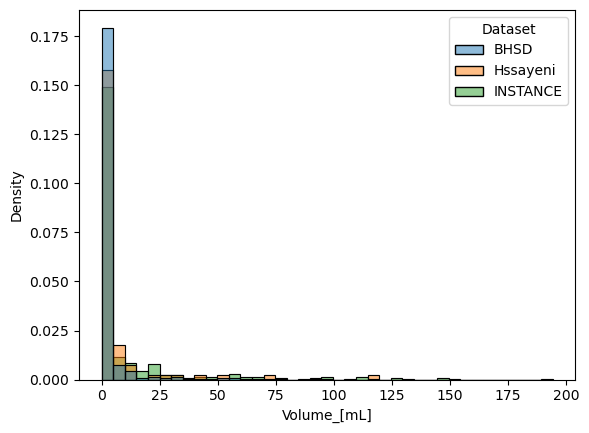

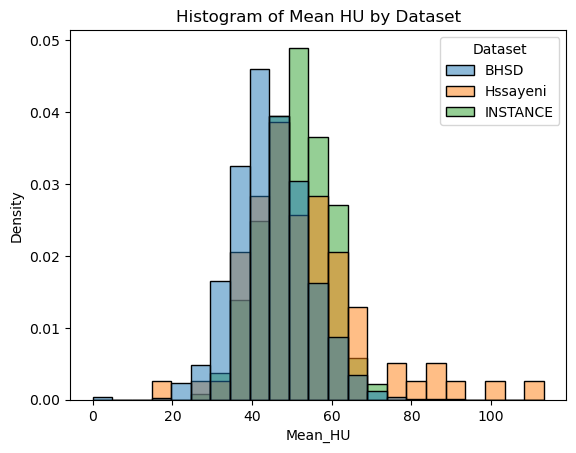

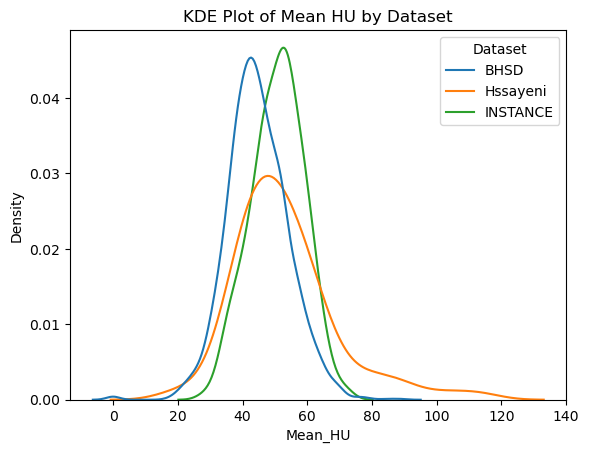

In [23]:
import seaborn as sns

print('Number of unique hemorrhage clusters by dataset:')
print(df['Dataset'].value_counts())

print(df.groupby('Dataset')['Mean_HU'].mean())

plt.figure()
sns.histplot(data=df, x='Volume_[mL]', hue='Dataset', stat="density", common_norm=False, binwidth=5)
plt.show()

plt.figure()
plt.title('Histogram of Mean HU by Dataset')
sns.histplot(data=df, x='Mean_HU', hue='Dataset', stat="density", common_norm=False, binwidth=5)
plt.show()

plt.figure()
plt.title('KDE Plot of Mean HU by Dataset')
sns.kdeplot(data=df, x='Mean_HU', hue='Dataset', common_norm=False)
plt.show()

### Differences in HU distributions by dataset: why?
* Hemorrhage type
    * If different hemorrhage types have different mean HU (see RSNA_BHSD_explore.ipynb), different datasets with different distributions of types may have different mean HU distributions altogether.
* Where is the data from?
    * Generally, [older hemorrhages = decreased HU value](https://www.sciencedirect.com/science/article/pii/S0303846722001391?via%3Dihub)
    * Data from trauma/ER centers (i.e. patients from accident with suspected hemorrhage) may have higher hemorrhage HU due to rapid scan acquisition
    * Conversely, follow-up scans from inpatients/outpatients might have decreased HU. The hemorrhage is no longer acute.


Unfortunately, none of the datasets fully specify the context of the scan (ER, outpatient, inpatient...) making further analysis difficult.
